# PyTorch AlexNet Training Record Visualization Notebook

功能：
1. 讀取 AlexNet 的 `training_record.pth`
2. 繪製 Train / Val Top-1、Top-5 Accuracy 曲線
3. 顯示 Test Top-1、Top-5 結果
4. 顯示 Batch-level Loss、訓練參數與時間摘要
5. 載入 AlexNet 最佳權重
6. 從 ImageNet-100 Validation 集隨機取一張圖片，顯示 Feature Maps、Logits 與 Top-5 預測

使用前請確認 AlexNet 資料夾、訓練程式、training record 與 best 權重路徑正確。


In [1]:
import os
import random
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import re
import pandas as pd



from torchvision import transforms, datasets, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU count:", torch.cuda.device_count())

Using device: cuda
GPU count: 1


In [2]:
# =========================================================
# AlexNet 實際訓練程式與權重設定
# =========================================================

model_type = "AlexNet"

# 與 AlexNet_train80_test20_RTX5090.py 相同的實驗資料夾
alexnet_dir = Path(r"C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet")
training_program_path = alexnet_dir / "AlexNet.py"

# 自動選取該資料夾中最新的 training record 與 best 權重，
# 避免手動指定到其他批次或舊模型。
record_candidates = sorted(
    alexnet_dir.glob("*_training_record__ImageNet_100.pth"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
weight_candidates = sorted(
    alexnet_dir.glob("*_best_ImageNet_100.pth"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not record_candidates:
    raise FileNotFoundError(f"找不到 training_record：{alexnet_dir}")
if not weight_candidates:
    raise FileNotFoundError(f"找不到 best 權重：{alexnet_dir}")

record_path = str(record_candidates[0])
weight_path = str(weight_candidates[0])

# 與實際訓練程式相同的 ImageNet-100 路徑
imagenet100_train_roots = [
    r"C:\Users\tlhorng\Desktop\ImageNet_100\train.X1",
    r"C:\Users\tlhorng\Desktop\ImageNet_100\train.X2",
    r"C:\Users\tlhorng\Desktop\ImageNet_100\train.X3",
    r"C:\Users\tlhorng\Desktop\ImageNet_100\train.X4",
]
imagenet100_val_roots = [
    r"C:\Users\tlhorng\Desktop\ImageNet_100\val.X"
]

print("training program:", training_program_path)
print("record:", record_path)
print("best weight:", weight_path)


training program: C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet\AlexNet.py
record: C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet\AlexNet_ep=90_lr=0.001_bs=128_20260811_2355_training_record__ImageNet_100.pth
best weight: C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet\AlexNet_ep=90_lr=0.001_bs=128_20260811_2355_best_ImageNet_100.pth


In [3]:
# =========================================================
# 讀取 training_record
# =========================================================


# 讀取實際訓練程式
training_program_text = training_program_path.read_text(encoding="utf-8")

def extract_value(pattern, text, cast_func):
    match = re.search(pattern, text)
    return cast_func(match.group(1)) if match else None


# 從訓練程式自動擷取設定值
program_split_seed = extract_value(r"\bsplit_seed\s*=\s*(\d+)", training_program_text, int)

program_test_ratio = extract_value(r"\btest_ratio\s*=\s*([0-9.]+)", training_program_text, float)

program_max_train_per_class = extract_value(
    r"train_dataset\s*=\s*ImageNet100\([\s\S]*?max_per_class\s*=\s*(\d+)",
    training_program_text,
    int
)

program_max_val_per_class = extract_value(
    r"val_dataset\s*=\s*ImageNet100\([\s\S]*?max_per_class\s*=\s*(\d+)",
    training_program_text,
    int
)

print("訓練程式設定：")
print("split_seed:", program_split_seed)
print("test_ratio:", program_test_ratio)
print("max train images/class:", program_max_train_per_class)
print("max val images/class:", program_max_val_per_class)


# =========================================================
# 讀取 training_record
# =========================================================
record = torch.load(record_path, map_location="cpu")

print("\ntraining_record 設定：")
print("record_path:", record_path)
print("model_name:", record.get("model_name"))
print("dataset_name:", record.get("dataset_name"))
print("EPOCHS:", record.get("EPOCHS"))
print("lr:", record.get("lr"))
print("batch_size:", record.get("batch_size"))
print("train_samples:", record.get("train_samples"))
print("val_samples:", record.get("val_samples"))


# 從 training_record 讀取實際實驗設定
record_split_seed = record.get("split_seed")
record_test_ratio = record.get("test_ratio")
record_max_train_per_class = record.get("original_train_max_per_class")
record_max_val_per_class = record.get("max_val_per_class")


# =========================================================
# 比對訓練程式與 training_record
# =========================================================
config_mismatches = []

if program_split_seed != record_split_seed:
    config_mismatches.append(f"split_seed：程式={program_split_seed}，record={record_split_seed}")

if program_test_ratio is not None and record_test_ratio is not None:
    if not math.isclose(program_test_ratio, record_test_ratio):
        config_mismatches.append(f"test_ratio：程式={program_test_ratio}，record={record_test_ratio}")

if (
    program_max_train_per_class is not None
    and record_max_train_per_class is not None
    and program_max_train_per_class != record_max_train_per_class
):
    config_mismatches.append(f"訓練每類上限：程式={program_max_train_per_class}，" f"record={record_max_train_per_class}")

if (
    program_max_val_per_class is not None
    and record_max_val_per_class is not None
    and program_max_val_per_class != record_max_val_per_class
):
    config_mismatches.append(f"驗證每類上限：程式={program_max_val_per_class}，" f"record={record_max_val_per_class}")


if config_mismatches:
    print("\n⚠️ 發現設定不一致：")
    for item in config_mismatches:
        print(" -", item)
else:
    print("\n✅ 訓練程式與 training_record 設定一致。")


# =========================================================
# 讀取訓練數據
# =========================================================
EPOCHS = record["EPOCHS"]
lr = record["lr"]
batch_size = record["batch_size"]

loss_list = record.get("loss_list", [])
train_loss_list = record.get("train_loss_list", [])
val_loss_list = record.get("val_loss_list", [])

train_acc1_list = record["train_acc1_list"]
train_acc5_list = record["train_acc5_list"]
val_acc1_list = record["val_acc1_list"]
val_acc5_list = record["val_acc5_list"]

# Test 僅使用最佳 Validation Top-1 權重評估一次
test_acc1 = record.get("test_acc1", None)
test_acc5 = record.get("test_acc5", None)

dataset_name = record.get("dataset_name", "Dataset")
record_model_name = record.get("model_name", model_type)

train_samples = record.get("train_samples")
if train_samples is not None:
    batches_per_epoch = math.ceil(train_samples / batch_size)
else:
    batches_per_epoch = max(1, len(loss_list) // EPOCHS)

print("batches_per_epoch:", batches_per_epoch)

訓練程式設定：
split_seed: 42
test_ratio: 0.2
max train images/class: 1300
max val images/class: 50

training_record 設定：
record_path: C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet\AlexNet_ep=90_lr=0.001_bs=128_20260811_2355_training_record__ImageNet_100.pth
model_name: AlexNet
dataset_name: ImageNet_100
EPOCHS: 90
lr: 0.001
batch_size: 128
train_samples: 104000
val_samples: 5000

✅ 訓練程式與 training_record 設定一致。
batches_per_epoch: 813


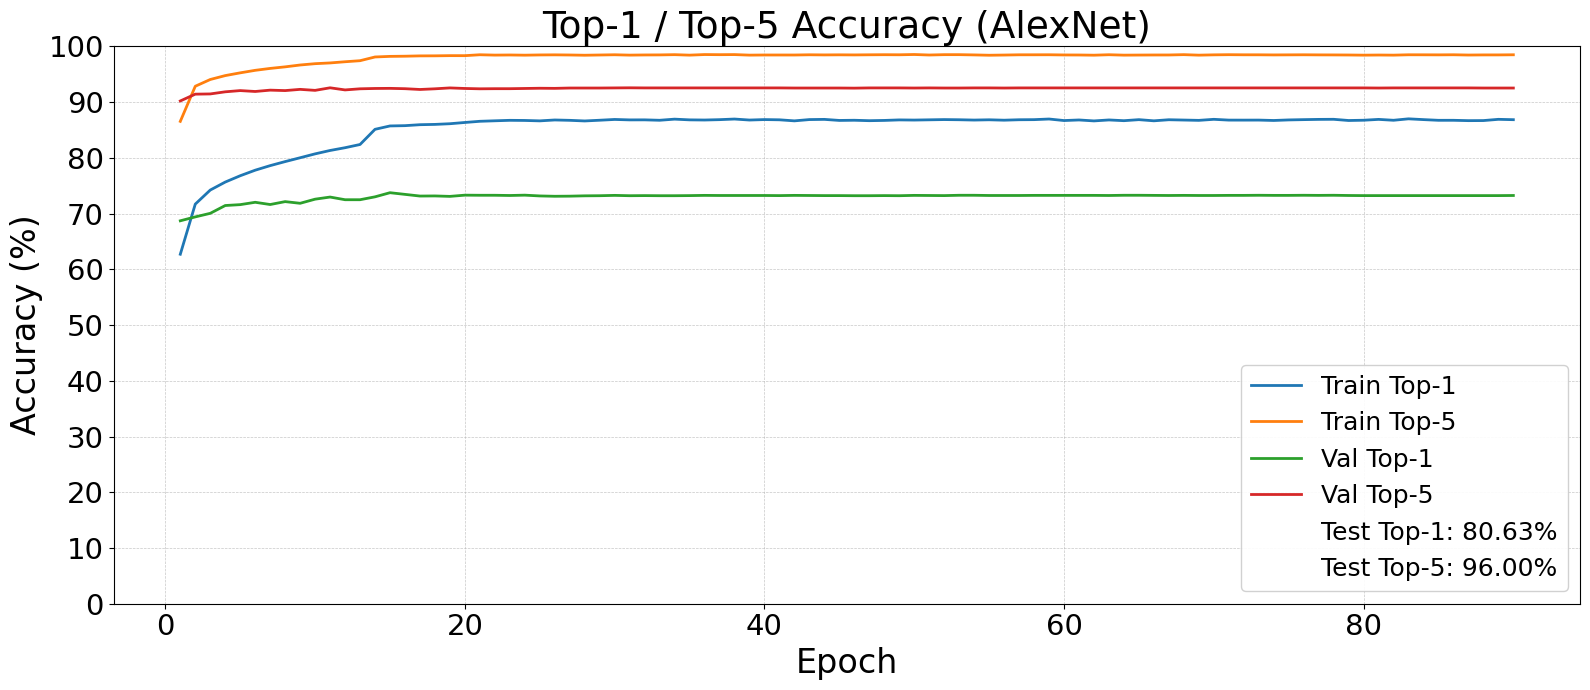

In [16]:
# =========================================================
# Top-1 / Top-5 Accuracy 曲線
# =========================================================
plt.figure(figsize=(16, 7))
epochs_x = range(1, len(train_acc1_list) + 1)
plt.plot(epochs_x, train_acc1_list, label="Train Top-1", linewidth=2)
plt.plot(epochs_x, train_acc5_list, label="Train Top-5", linewidth=2)
plt.plot(epochs_x, val_acc1_list, label="Val Top-1", linewidth=2)
plt.plot(epochs_x, val_acc5_list, label="Val Top-5", linewidth=2)

# Test 僅評估一次，數值放在圖例中
if test_acc1 is not None:
    plt.plot([], [], linestyle="None", label=f"Test Top-1: {float(test_acc1):.2f}%")
if test_acc5 is not None:
    plt.plot([], [], linestyle="None", label=f"Test Top-5: {float(test_acc5):.2f}%")

plt.xlabel("Epoch", fontsize=24)
plt.ylabel("Accuracy (%)", fontsize=24)
plt.title(f"Top-1 / Top-5 Accuracy ({record_model_name})", fontsize=27)
plt.legend(fontsize=18, loc="lower right", framealpha=0.9)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.xticks(fontsize=21)
plt.yticks(range(0, 101, 10), fontsize=21)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

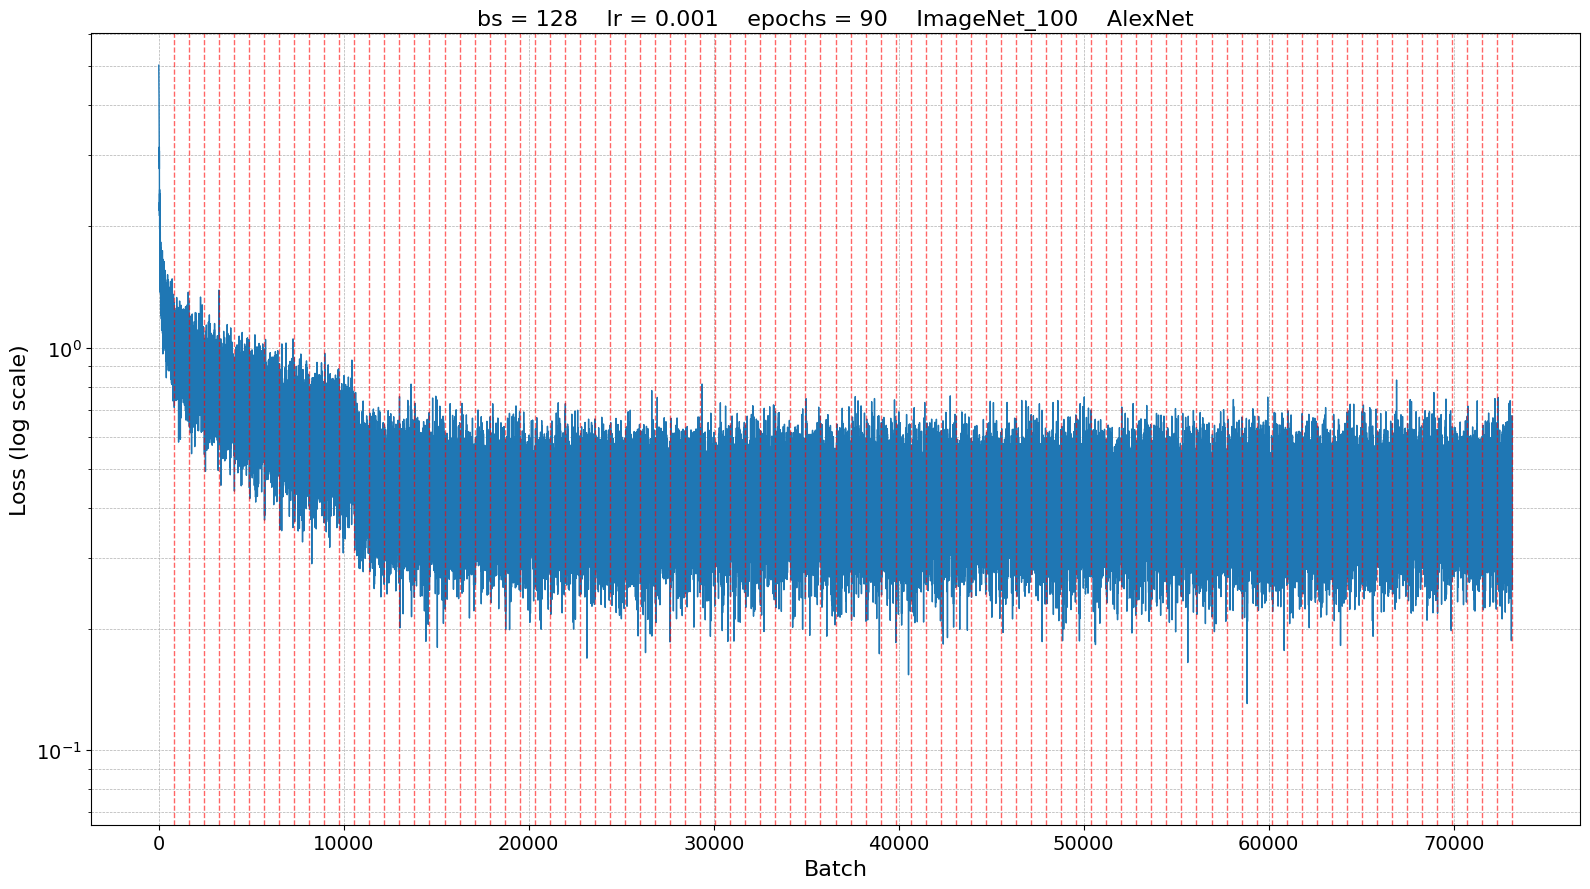

In [5]:
# =========================================================
# 畫 Batch-level Loss 曲線，y 軸使用 log scale
# =========================================================
plt.figure(figsize=(16, 9))

x = range(1, len(loss_list) + 1)
plt.plot(x, loss_list, linewidth=1)

plt.xlabel('Batch', fontsize=16)
plt.ylabel('Loss (log scale)', fontsize=16)
plt.title(f'bs = {batch_size}    lr = {lr}    epochs = {EPOCHS}    {dataset_name}    {record_model_name}', fontsize=16)

plt.yscale('log')

# 自動設定 y 軸範圍，避免固定 1e-4~1 時某些模型看不到
positive_losses = [v for v in loss_list if v > 0]
if len(positive_losses) > 0:
    ymin = max(min(positive_losses) * 0.5, 1e-6)
    ymax = max(positive_losses) * 1.2
    plt.ylim(ymin, ymax)

plt.grid(True, which="both", ls="--", lw=0.5)

# 每個 epoch 畫紅色虛線
for epoch_idx in range(1, EPOCHS + 1):
    x_pos = epoch_idx * batches_per_epoch
    plt.axvline(x=x_pos, color='red', linestyle='--', linewidth=1, alpha=0.6)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# =========================================================
# 訓練結果、參數與時間摘要
# =========================================================
num_epochs = len(train_acc1_list)
final_train_top1, final_train_top5 = train_acc1_list[-1], train_acc5_list[-1]
final_val_top1, final_val_top5 = val_acc1_list[-1], val_acc5_list[-1]
best_epoch = record.get("best_epoch")
best_val_top1 = record.get("best_val_acc1", max(val_acc1_list))
best_val_top5 = record.get("best_val_acc5")
test_top1, test_top5 = record.get("test_acc1"), record.get("test_acc5")

print("=" * 70)
print(f"{record_model_name} 訓練結果摘要")
print("=" * 70)
print(f"模型：{record_model_name}")
print(f"資料集：{dataset_name}")
print(f"總 Epoch 數：{num_epochs}")
print("\n【最後一個 Epoch】")
print(f"Train Top-1：{final_train_top1:.2f}%")
print(f"Train Top-5：{final_train_top5:.2f}%")
print(f"Val Top-1：{final_val_top1:.2f}%")
print(f"Val Top-5：{final_val_top5:.2f}%")
print("\n【最佳 Validation 結果】")
if best_epoch is not None: print(f"最佳 Epoch：{best_epoch}")
print(f"最佳 Val Top-1：{float(best_val_top1):.2f}%")
if best_val_top5 is not None: print(f"最佳 Val Top-5：{float(best_val_top5):.2f}%")
print("\n【Test 結果】")
print(f"Test Top-1：{float(test_top1):.2f}%" if test_top1 is not None else "Test Top-1：training_record 中沒有資料")
print(f"Test Top-5：{float(test_top5):.2f}%" if test_top5 is not None else "Test Top-5：training_record 中沒有資料")

print("\n" + "=" * 70)
print("訓練參數")
print("=" * 70)
print(f"Epoch：{record.get('EPOCHS')}")
print(f"Batch Size：{record.get('batch_size')}")
print(f"Learning Rate：{record.get('lr')}")
print(f"Weight Decay：{record.get('weight_decay')}")
print(f"Optimizer：{record.get('optimizer')}")
print(f"Momentum：{record.get('momentum')}")
print(f"Number of Classes：{record.get('num_classes')}")
print(f"Train Samples：{record.get('train_samples')}")
print(f"Validation Samples：{record.get('val_samples')}")
print(f"Test Samples：{record.get('test_samples')}")
print(f"Train/Test Split Ratio：{record.get('train_ratio')} / {record.get('test_ratio')}")
print(f"Split Seed：{record.get('split_seed')}")

# 每個 Epoch 的時間與 Learning Rate 保留在變數中，不顯示大型表格
epoch_time_sec = record.get("epoch_time_list_sec", [])
epoch_time_min = record.get("epoch_time_list_min", [])
lr_list = record.get("lr_list", [])
if not epoch_time_min and epoch_time_sec:
    epoch_time_min = [value / 60 for value in epoch_time_sec]

avg_epoch_time_min = record.get("avg_epoch_time_min")
total_epoch_time_min = record.get("total_epoch_time_min")
test_time_min = record.get("test_time_min")
program_total_min = record.get("program_total_min")

print("\n" + "=" * 70)
print("時間統計")
print("=" * 70)
if avg_epoch_time_min is not None:
    print(f"平均每個 Epoch：{float(avg_epoch_time_min):.2f} 分鐘")
elif epoch_time_min:
    print(f"平均每個 Epoch：{sum(epoch_time_min) / len(epoch_time_min):.2f} 分鐘")
else:
    print("平均每個 Epoch：無資料")
if total_epoch_time_min is not None:
    print(f"所有 Epoch 總時間：{float(total_epoch_time_min):.2f} 分鐘")
elif epoch_time_min:
    print(f"所有 Epoch 總時間：{sum(epoch_time_min):.2f} 分鐘")
else:
    print("所有 Epoch 總時間：無資料")
print(f"Test 評估時間：{float(test_time_min):.2f} 分鐘" if test_time_min is not None else "Test 評估時間：無資料")
print(f"程式總耗時：{float(program_total_min):.2f} 分鐘" if program_total_min is not None else "程式總耗時：無資料")


AlexNet 訓練結果摘要
模型：AlexNet
資料集：ImageNet_100
總 Epoch 數：90

【最後一個 Epoch】
Train Top-1：86.84%
Train Top-5：98.48%
Val Top-1：73.24%
Val Top-5：92.52%

【最佳 Validation 結果】
最佳 Epoch：15
最佳 Val Top-1：73.74%
最佳 Val Top-5：92.46%

【Test 結果】
Test Top-1：80.63%
Test Top-5：96.00%

訓練參數
Epoch：90
Batch Size：128
Learning Rate：0.001
Weight Decay：0.0005
Optimizer：SGD
Momentum：0.9
Number of Classes：100
Train Samples：104000
Validation Samples：5000
Test Samples：26000
Train/Test Split Ratio：0.8 / 0.2
Split Seed：42

時間統計
平均每個 Epoch：0.66 分鐘
所有 Epoch 總時間：59.53 分鐘
Test 評估時間：0.57 分鐘
程式總耗時：60.11 分鐘


## AlexNet Feature Map 視覺化

此區塊使用前請確認：
1. `weight_path` 指向 AlexNet 的最佳權重檔
2. `model_type = "AlexNet"`
3. `imagenet100_val_roots` 指向 ImageNet-100 的 Validation 資料夾
4. `record_path` 與 `weight_path` 屬於同一次 AlexNet 訓練實驗


In [7]:
# =========================================================
# AlexNet Dataset definition for feature map visualization
# =========================================================
class ImageNet100(Dataset):
    """
    僅讀取 ImageNet-100 Validation 資料，
    用於隨機抽取圖片、Feature Map 與分類結果分析。
    """

    def __init__(
        self,
        root_list,
        transform=None,
        train_class_to_idx=None,
        max_per_class=50
    ):
        self.transform = transform

        # 使用訓練紀錄中的類別索引，
        # 確保圖片標籤與 AlexNet 輸出類別完全一致
        if train_class_to_idx is None:
            raise ValueError(
                "必須提供 training_record 中的 train_class_to_idx"
            )

        self.class_to_idx = train_class_to_idx
        self.samples = []

        # 讀取 Validation 資料
        for cls, cls_idx in self.class_to_idx.items():
            class_paths = []

            for root in root_list:
                cls_path = os.path.join(root, cls)

                if not os.path.isdir(cls_path):
                    continue

                # 與 AlexNet 訓練程式相同：
                # 只讀取 jpg / jpeg，並依檔名排序
                fnames = sorted([
                    f for f in os.listdir(cls_path)
                    if f.lower().endswith((".jpg", ".jpeg"))
                ])

                class_paths.extend(
                    os.path.join(cls_path, fname)
                    for fname in fnames
                )

            # 與訓練程式相同，依完整路徑排序
            class_paths = sorted(class_paths)

            # Validation 每類最多讀取 50 張
            if max_per_class is not None:
                class_paths = class_paths[:max_per_class]

            for path in class_paths:
                self.samples.append((path, cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]

        # 轉成 RGB，確保輸入為 3 通道
        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
# =========================================================
# Build AlexNet + Validation Dataset
# =========================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 從 training_record 取得實際類別數量
num_classes = record["num_classes"]

# =========================================================
# 建立 AlexNet
# =========================================================
model = models.alexnet(weights=None)

# 將最後分類層調整為 ImageNet-100
model.classifier[6] = nn.Linear(
    in_features=4096,
    out_features=num_classes
)

# =========================================================
# Validation 前處理
# 必須與 AlexNet_train80_test20_RTX5090.py 一致
# =========================================================
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# =========================================================
# 建立 Validation Dataset
# =========================================================
class_to_idx = record["class_to_idx"]

val_dataset = ImageNet100(
    root_list=imagenet100_val_roots,
    transform=val_transform,
    train_class_to_idx=class_to_idx,
    max_per_class=50
)

# 將類別編號轉回類別名稱
idx_to_class = {
    index: class_name
    for class_name, index in val_dataset.class_to_idx.items()
}

# 給圖片反正規化顯示時使用
image_mean = IMAGENET_MEAN
image_std = IMAGENET_STD

print("model_type:", model_type)
print("num_classes:", num_classes)
print("validation samples:", len(val_dataset))
print("class count:", len(class_to_idx))

model_type: AlexNet
num_classes: 100
validation samples: 5000
class count: 100


In [9]:
# =========================================================
# Load trained AlexNet weight
# =========================================================

if not weight_path:
    raise ValueError(
        "weight_path 不可為空，必須載入訓練完成的 AlexNet 權重。"
    )

# 讀取最佳權重
state = torch.load(
    weight_path,
    map_location="cpu",
    weights_only=True
)

# 處理 DataParallel 儲存時可能產生的 module. 前綴
state = {
    key.replace("module.", "", 1) if key.startswith("module.") else key: value
    for key, value in state.items()
}

missing, unexpected = model.load_state_dict(
    state,
    strict=True
)

print("Loaded AlexNet weight:", weight_path)
print("missing keys:", missing)
print("unexpected keys:", unexpected)

# 移至 GPU 或 CPU，並切換為推論模式
model = model.to(device)
model.eval()

Loaded AlexNet weight: C:\Users\tlhorng\Desktop\謝彥德\論文程式\ch2_各類影像辨識網路\AlexNet\AlexNet_ep=90_lr=0.001_bs=128_20260811_2355_best_ImageNet_100.pth
missing keys: []
unexpected keys: []


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [10]:
# =========================================================
# Register AlexNet hooks
# =========================================================

feature_maps = {}


def hook_fn(name):
    def hook(module, inputs, output):
        # 將 Feature Map 複製到 CPU，避免持續占用 GPU 記憶體
        feature_maps[name] = output.detach().cpu()

    return hook


hooks = []

# AlexNet 五個卷積層
hooks.append(
    model.features[0].register_forward_hook(
        hook_fn("conv1")
    )
)

hooks.append(
    model.features[3].register_forward_hook(
        hook_fn("conv2")
    )
)

hooks.append(
    model.features[6].register_forward_hook(
        hook_fn("conv3")
    )
)

hooks.append(
    model.features[8].register_forward_hook(
        hook_fn("conv4")
    )
)

hooks.append(
    model.features[10].register_forward_hook(
        hook_fn("conv5")
    )
)

print("AlexNet hooks registered:", len(hooks))

AlexNet hooks registered: 5


In [11]:
# =========================================================
# 從 ImageNet-100 Validation 集隨機取一張圖片並 forward
# =========================================================

if len(val_dataset) == 0:
    raise RuntimeError("Validation Dataset 沒有可用圖片。")

# 為了讓每次執行都能抽到不同圖片
rand_idx = random.randrange(len(val_dataset))

# 取得經過 Resize、CenterCrop、Normalize 的圖片
image, label_idx = val_dataset[rand_idx]

# 增加 Batch 維度
# 原始尺寸：(3, 224, 224)
# 輸入尺寸：(1, 3, 224, 224)
image_batch = image.unsqueeze(0).to(device)

# AlexNet 推論
with torch.no_grad():
    outputs = model(image_batch)

# 取得真實類別名稱
label_name = idx_to_class[label_idx]

# 移除 Hook，避免後續 forward 重複記錄 Feature Map
for hook in hooks:
    hook.remove()

print("random index:", rand_idx)
print("label index:", label_idx)
print("label name:", label_name)
print("input shape:", image_batch.shape)
print("output shape:", outputs.shape)

random index: 3509
label index: 70
label name: n01877812
input shape: torch.Size([1, 3, 224, 224])
output shape: torch.Size([1, 100])


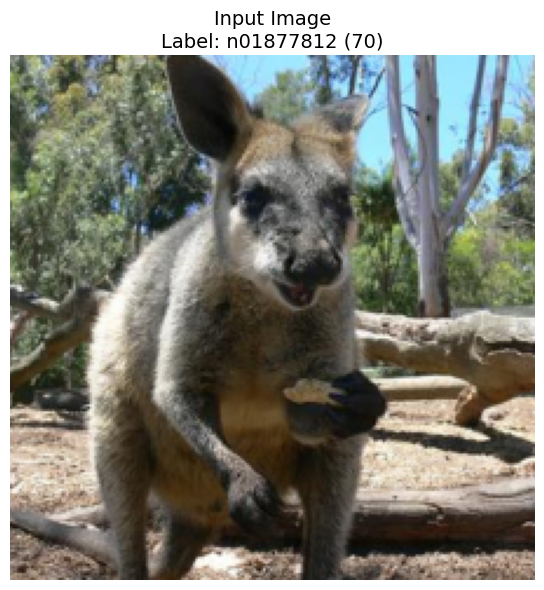

In [12]:
# =========================================================
# 顯示 AlexNet Input Image + Label
# =========================================================

def denorm(img, mean, std):
    """
    將 Normalize 後的影像還原成可顯示的 RGB 影像。
    """
    mean = torch.tensor(
        mean,
        dtype=img.dtype,
        device=img.device
    ).view(3, 1, 1)

    std = torch.tensor(
        std,
        dtype=img.dtype,
        device=img.device
    ).view(3, 1, 1)

    return img.cpu() * std.cpu() + mean.cpu()


# 還原 ImageNet Normalize
img_show = denorm(
    image,
    image_mean,
    image_std
).clamp(0, 1)

# 轉換為 matplotlib 使用的格式：
# PyTorch：     (C, H, W)
# matplotlib：  (H, W, C)
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img_show)
plt.axis("off")

plt.title(
    f"Input Image\n"
    f"Label: {label_name} ({label_idx})",
    fontsize=14
)

plt.tight_layout()
plt.show()

Layer: conv1, feature map shape: (1, 64, 55, 55)


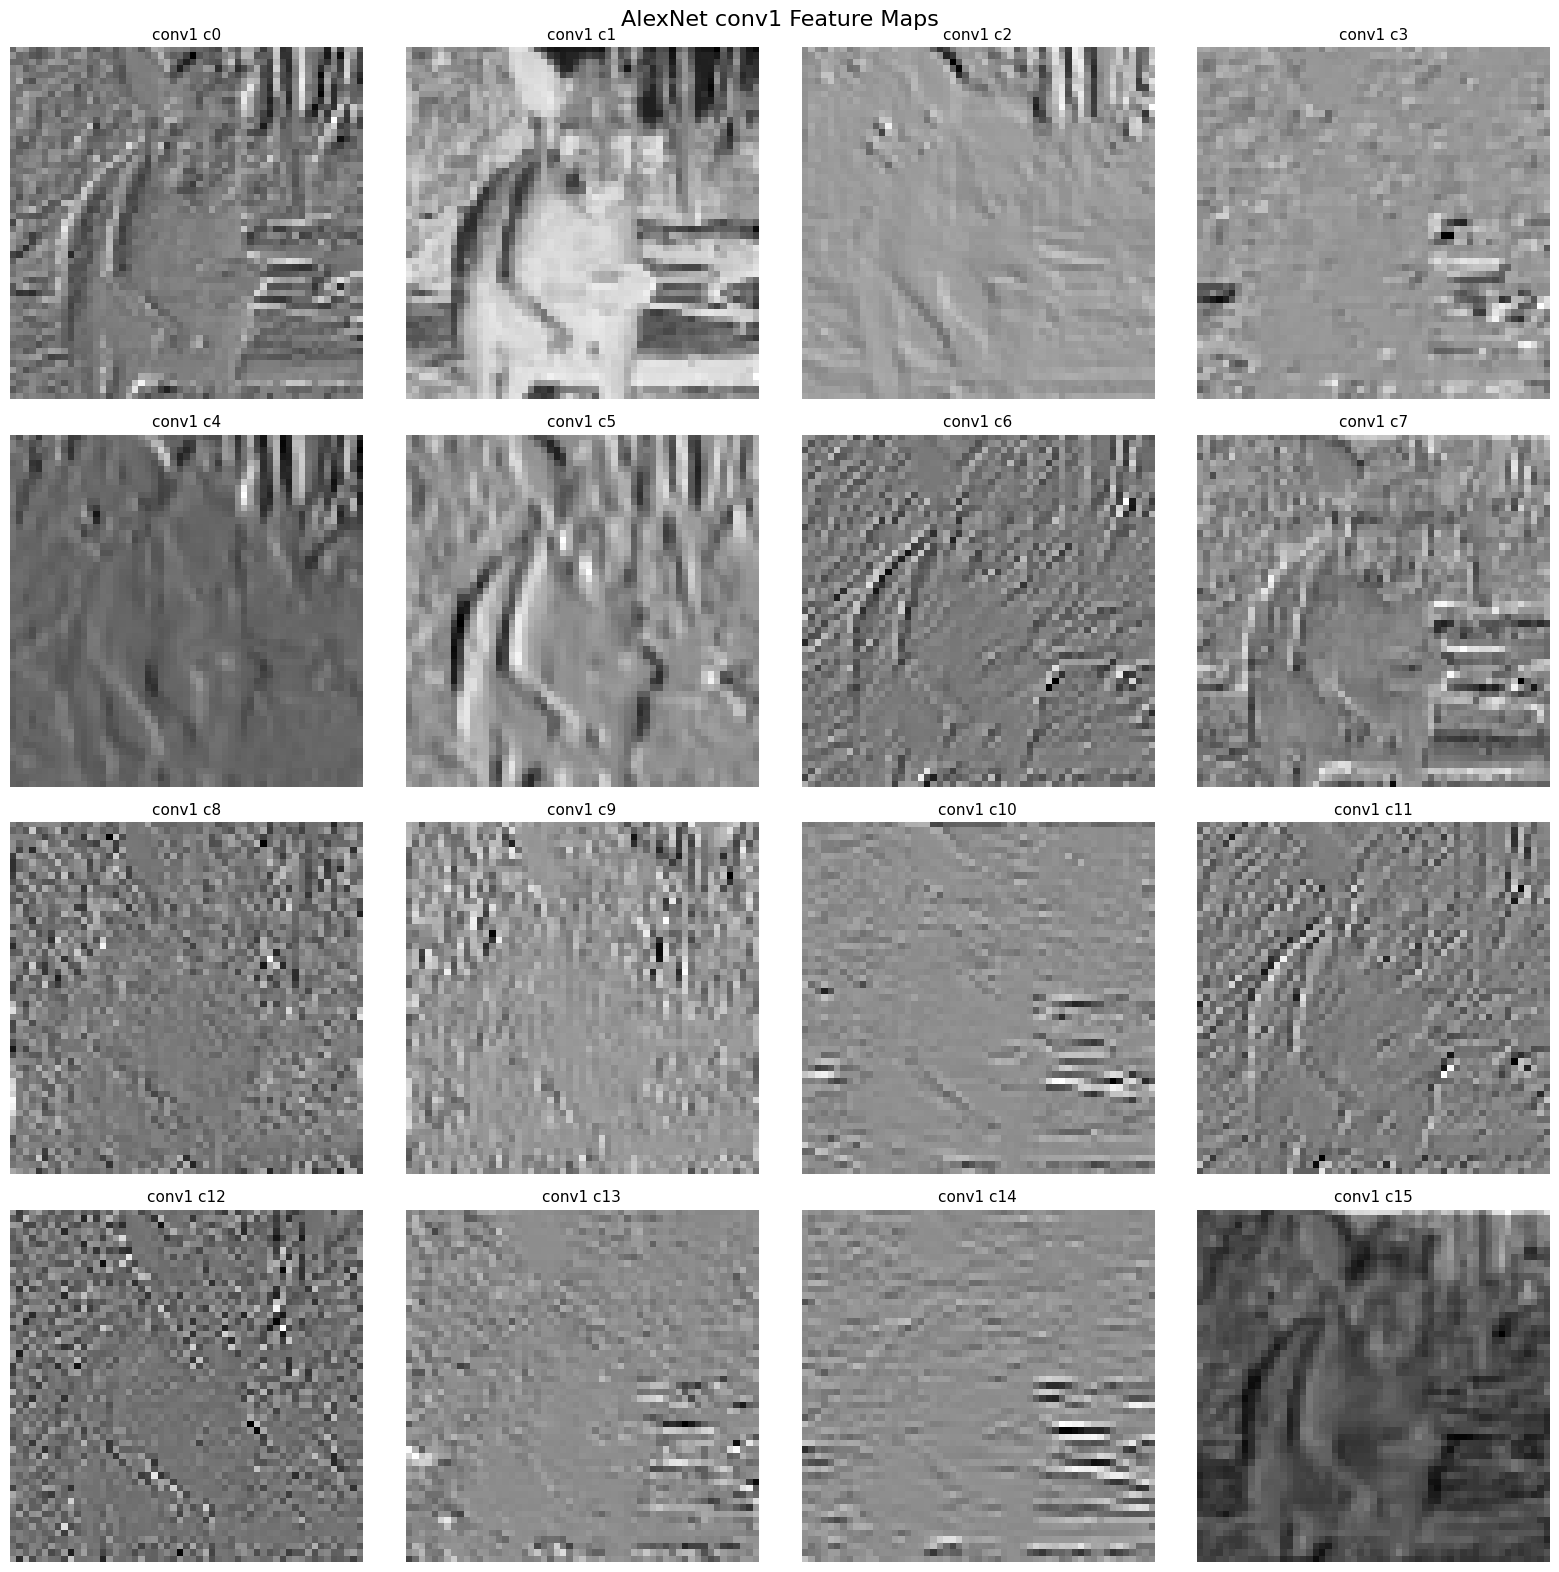

Layer: conv2, feature map shape: (1, 192, 27, 27)


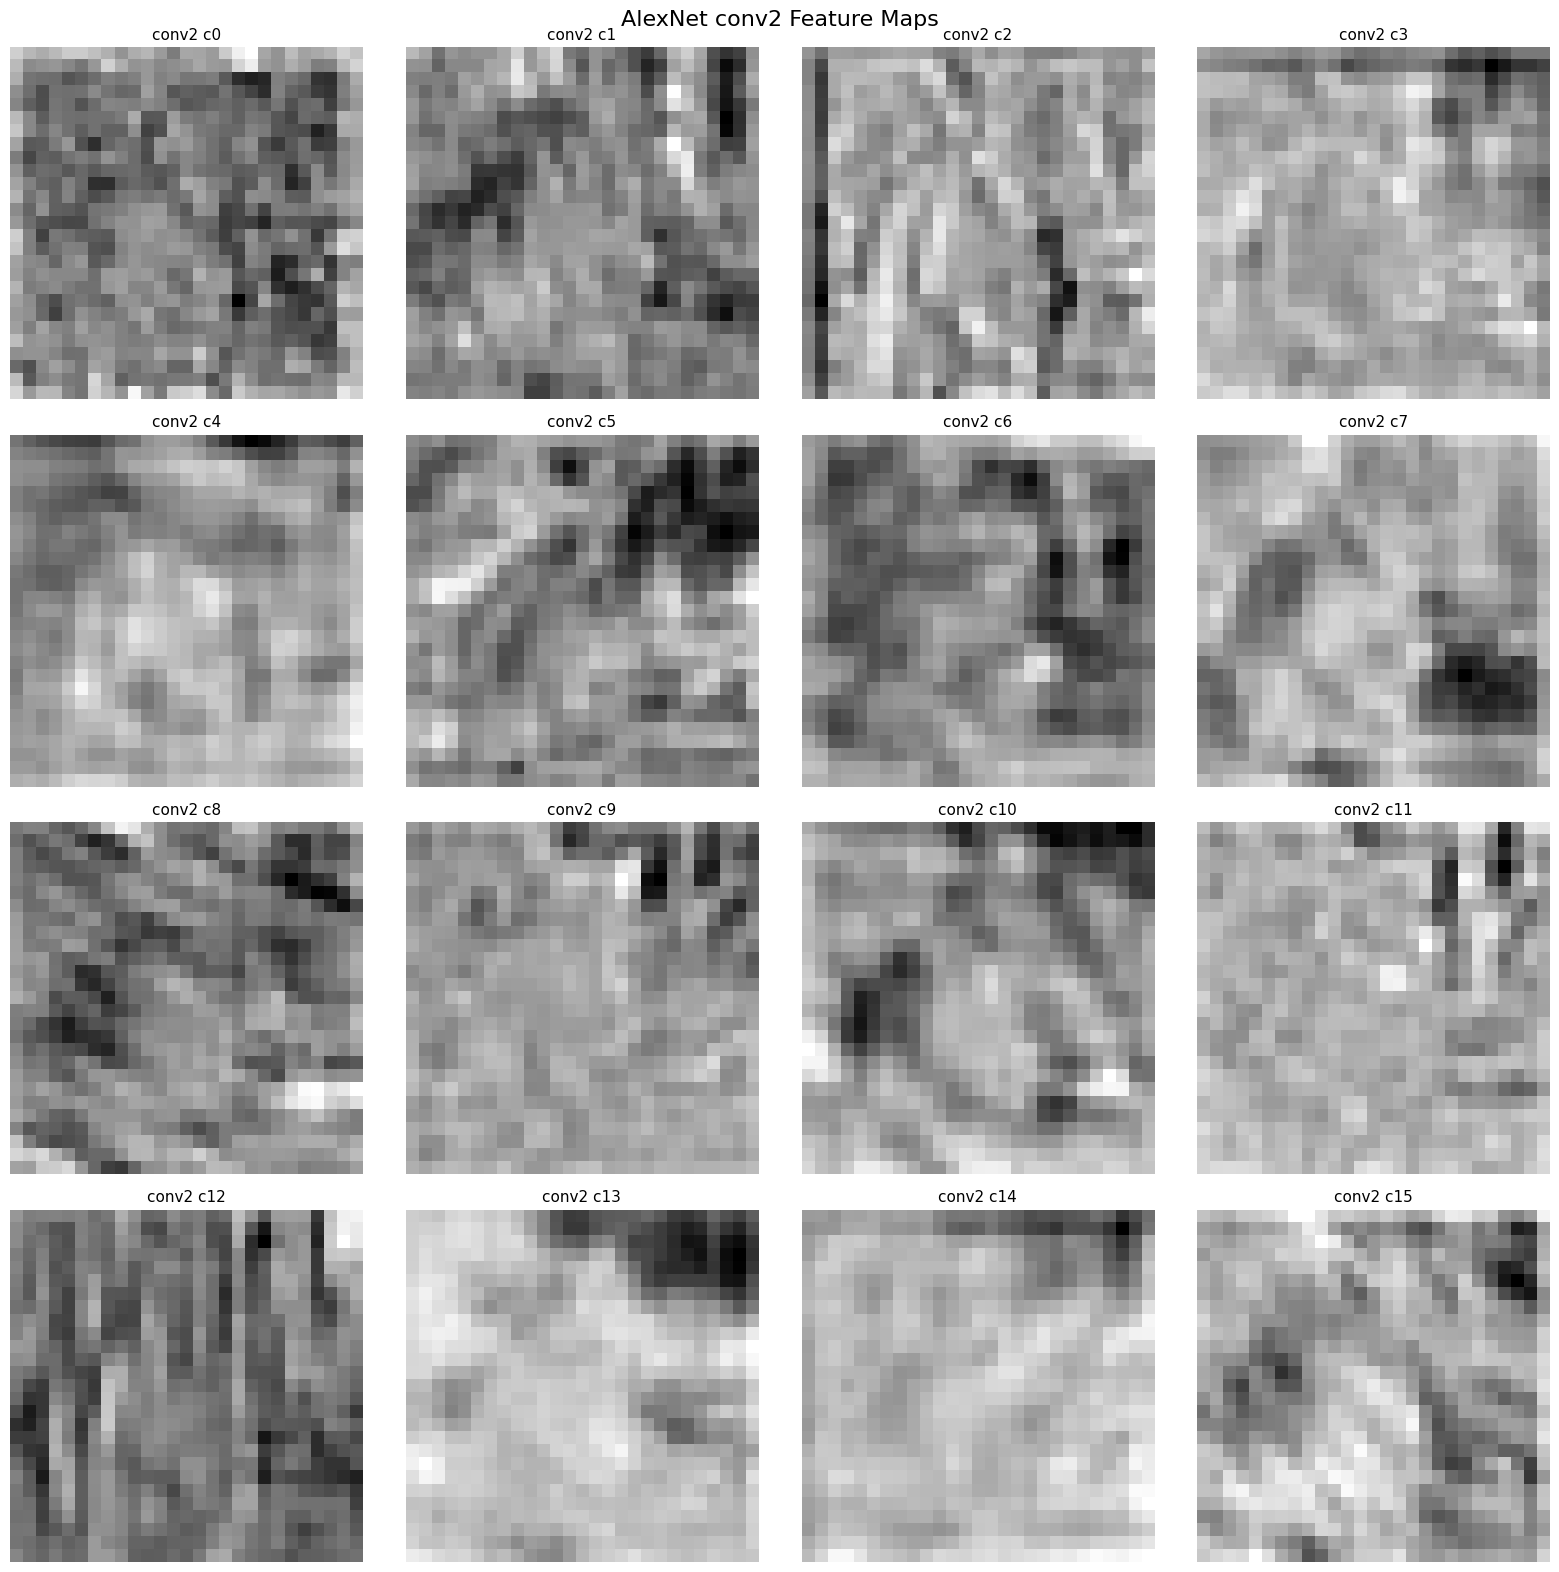

Layer: conv3, feature map shape: (1, 384, 13, 13)


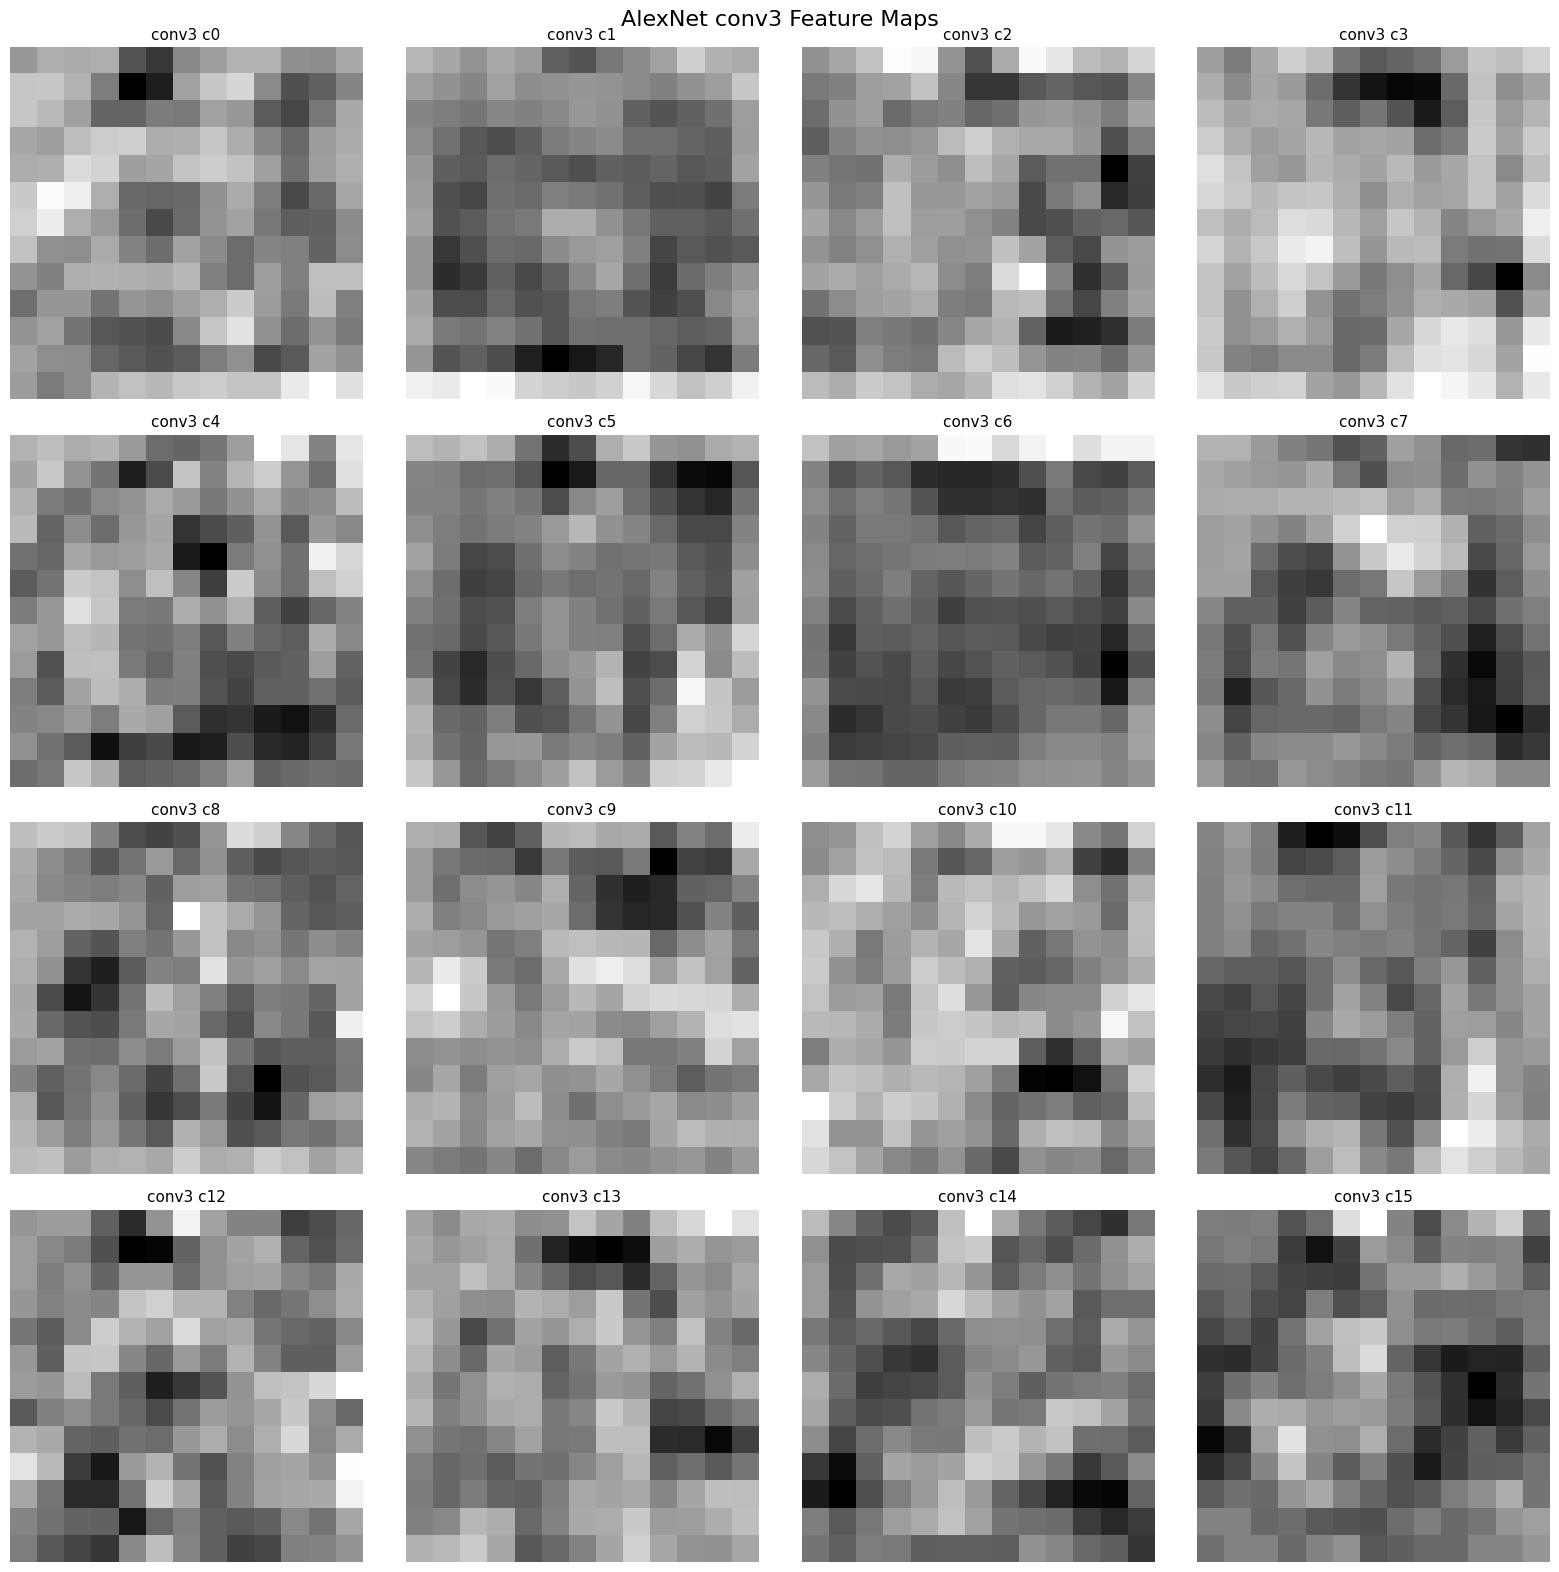

Layer: conv4, feature map shape: (1, 256, 13, 13)


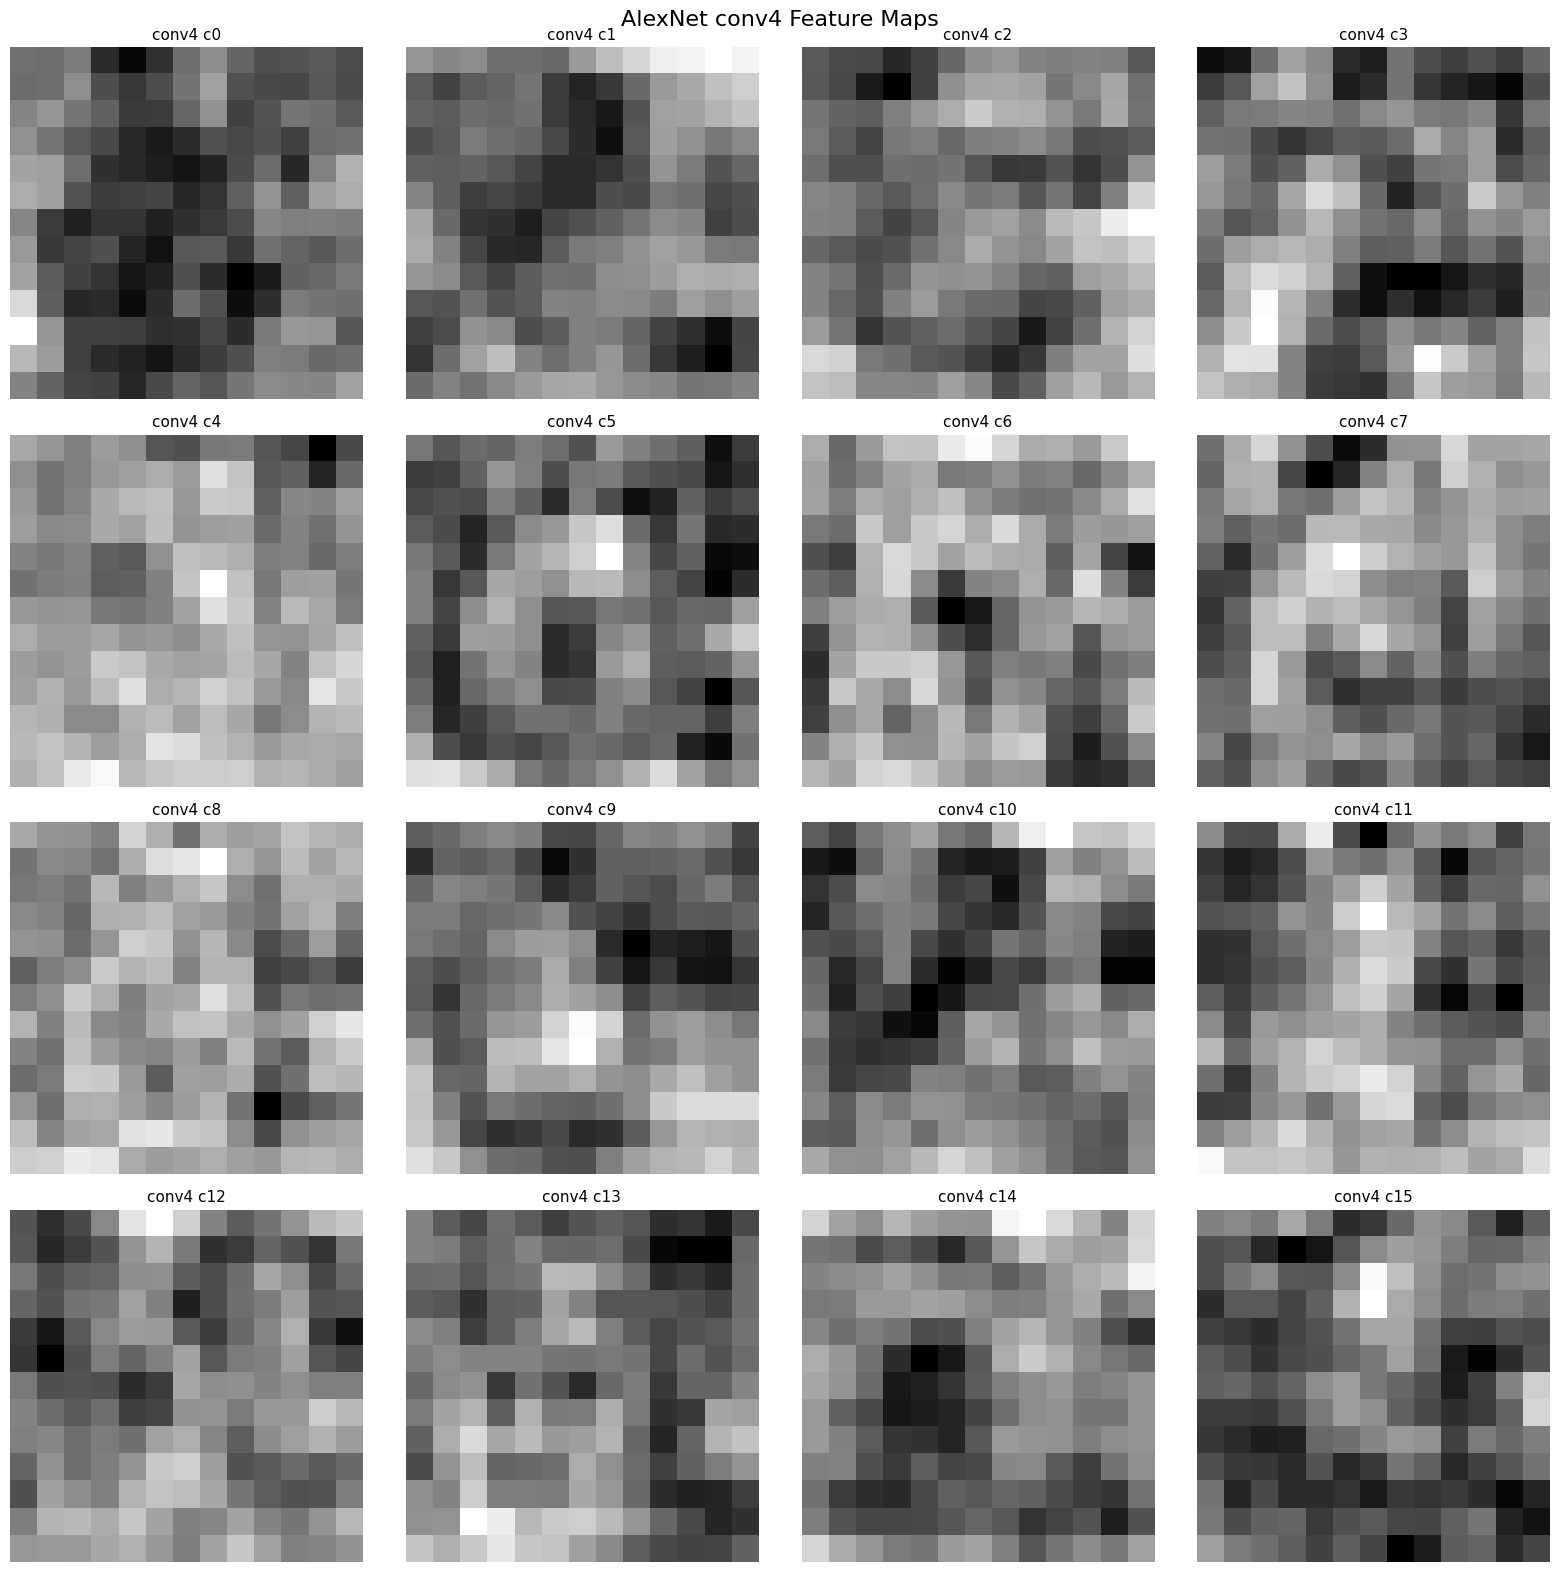

Layer: conv5, feature map shape: (1, 256, 13, 13)


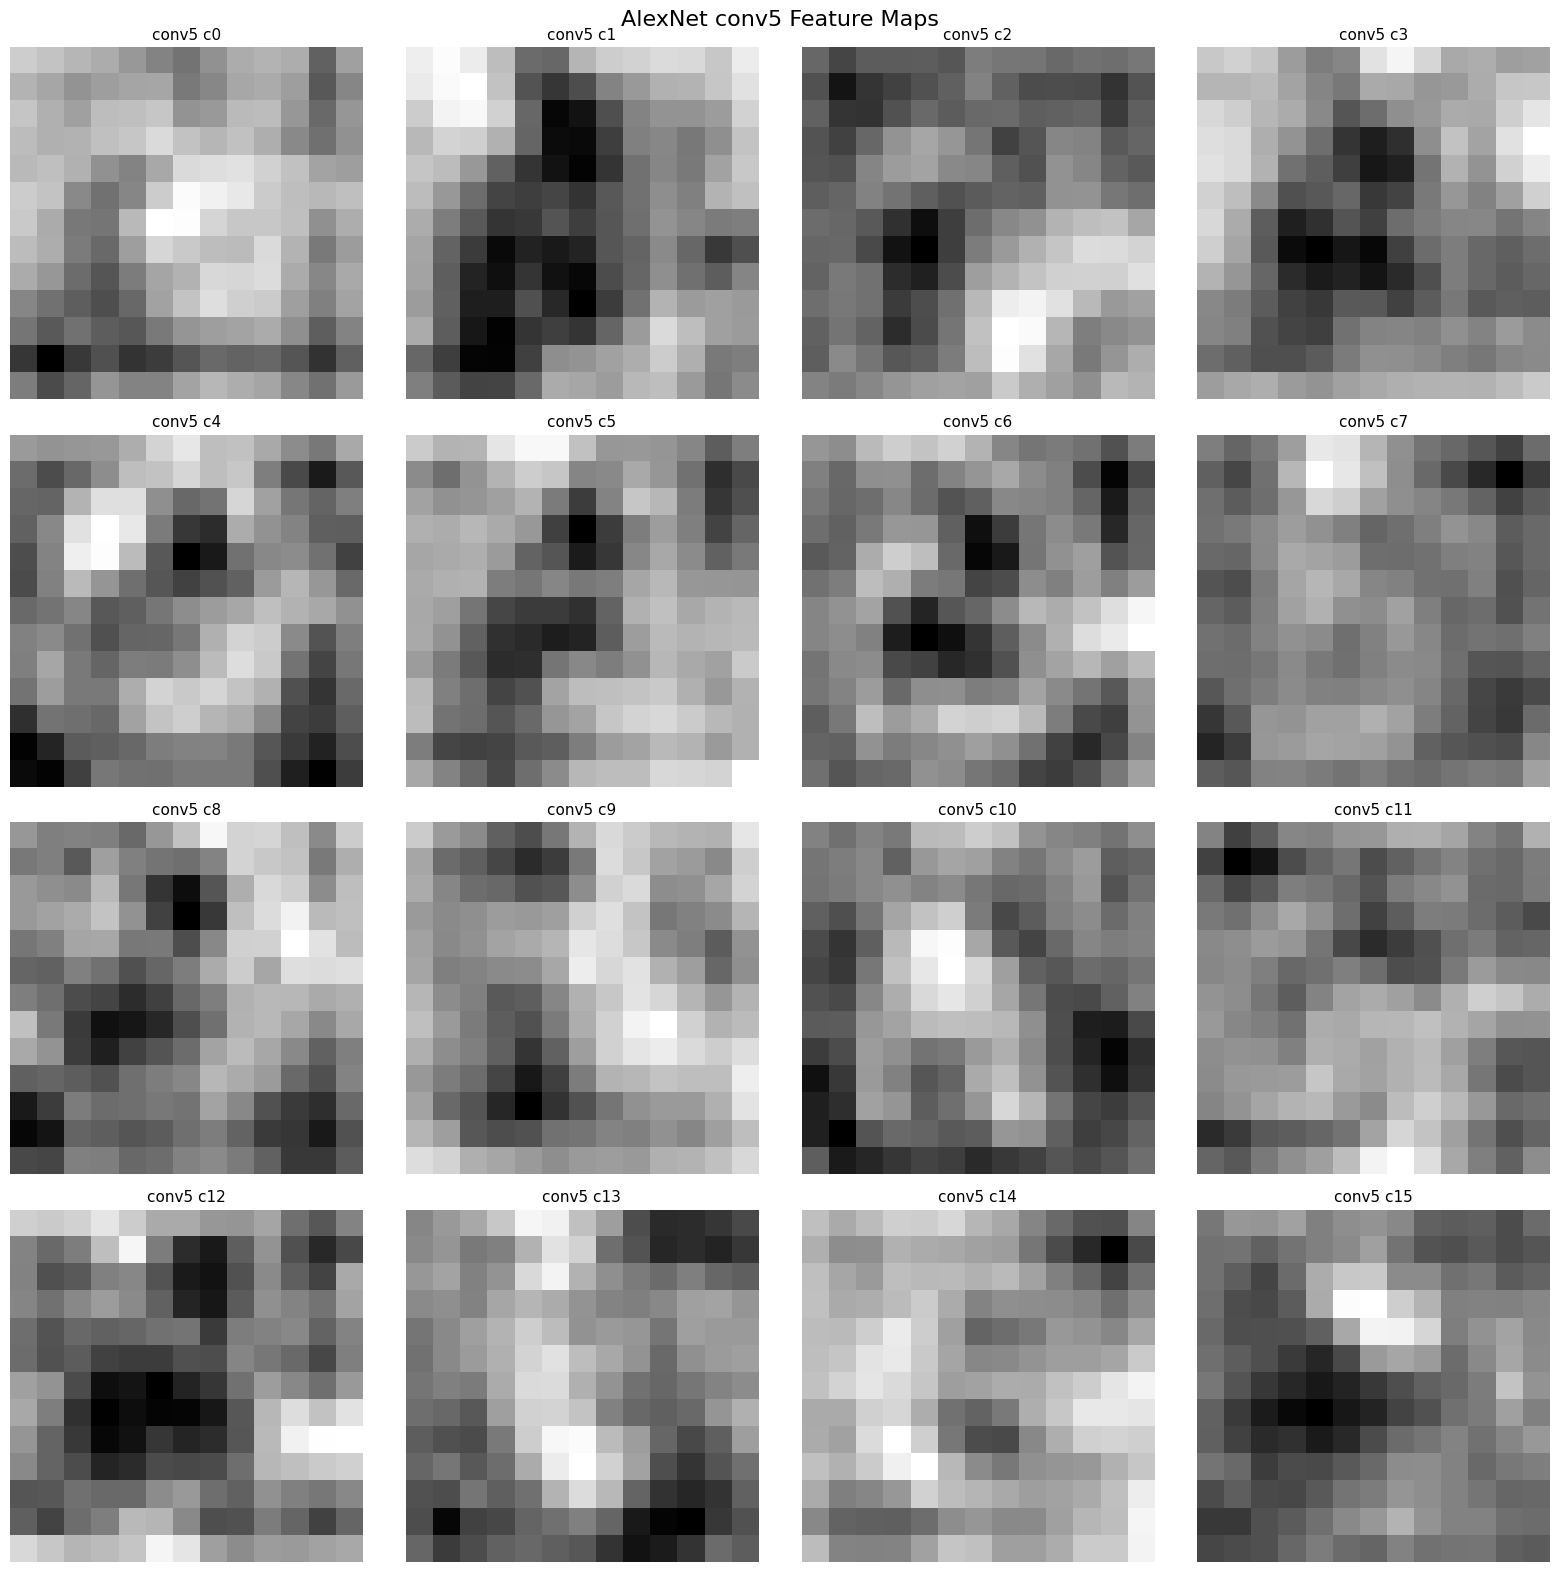

In [13]:
# =========================================================
# 顯示 AlexNet Feature Map
# =========================================================

def show_feature_map(
    tensor,
    layer_name,
    max_channel=16
):
    """
    顯示單一 AlexNet 卷積層的 Feature Map。

    tensor shape:
        (batch_size, channels, height, width)
    """

    # 目前只輸入一張圖片，因此取第 0 張
    fmap = tensor[0]

    # 最多顯示指定數量的通道
    num_channels = min(
        max_channel,
        fmap.shape[0]
    )

    cols = 4
    rows = math.ceil(num_channels / cols)

    plt.figure(figsize=(16, 4 * rows))

    for channel_idx in range(num_channels):
        plt.subplot(rows, cols, channel_idx + 1)

        plt.imshow(
            fmap[channel_idx].numpy(),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(f"{layer_name} c{channel_idx}", fontsize=11)

    plt.suptitle(f"AlexNet {layer_name} Feature Maps", fontsize=16)

    plt.tight_layout()
    plt.show()


# 依照 conv1～conv5 顯示 Feature Map
for layer_name, fmap in feature_maps.items():
    print(
        f"Layer: {layer_name}, "
        f"feature map shape: {tuple(fmap.shape)}"
    )

    show_feature_map(fmap, layer_name, max_channel=16)

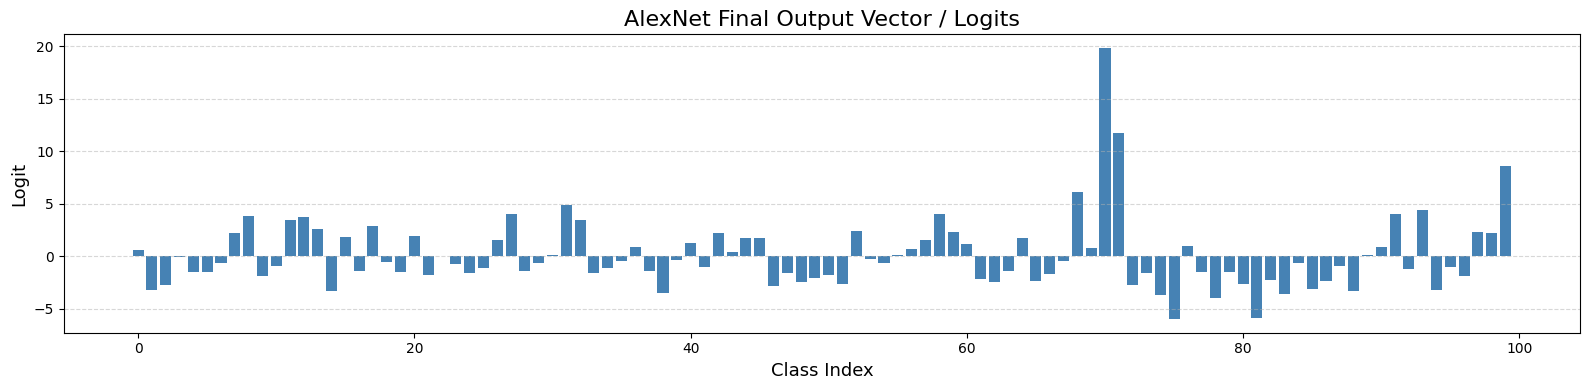

True Label: n01877812 (70)
Predicted Label: n01877812 (70)
Predicted Logit: 19.8241


In [14]:
# =========================================================
# AlexNet Final Output Vector / Logits
# =========================================================

# 取得 AlexNet 對 100 個類別的輸出分數
fc_vec = outputs[0].detach().cpu().numpy()

plt.figure(figsize=(16, 4))

plt.bar(
    range(len(fc_vec)),
    fc_vec,
    color="steelblue"
)

plt.title("AlexNet Final Output Vector / Logits", fontsize=16)

plt.xlabel("Class Index", fontsize=13)

plt.ylabel("Logit", fontsize=13)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# =========================================================
# Top-1 預測結果
# =========================================================

pred_class_idx = outputs.argmax(
    dim=1
).item()

pred_class_name = idx_to_class[
    pred_class_idx
]

print(
    f"True Label: "
    f"{label_name} ({label_idx})"
)

print(
    f"Predicted Label: "
    f"{pred_class_name} ({pred_class_idx})"
)

print(f"Predicted Logit: " f"{fc_vec[pred_class_idx]:.4f}")

In [15]:
# =========================================================
# AlexNet Top-5 Prediction
# =========================================================

# 將 100 個 Logit 轉換為機率
probabilities = torch.softmax(
    outputs,
    dim=1
)[0]

# 取得機率最高的前 5 個類別
top_k = min(5, num_classes)

top5_prob, top5_idx = torch.topk(
    probabilities,
    k=top_k
)

print("AlexNet Top-5 Prediction:")

for rank, (class_idx, probability) in enumerate(
    zip(
        top5_idx.tolist(),
        top5_prob.tolist()
    ),
    start=1
):
    class_name = idx_to_class.get(
        class_idx,
        str(class_idx)
    )

    print(
        f"Top-{rank}: "
        f"{class_name} ({class_idx})  "
        f"prob = {probability * 100:.4f}%"
    )

AlexNet Top-5 Prediction:
Top-1: n01877812 (70)  prob = 99.9688%
Top-2: n01883070 (71)  prob = 0.0296%
Top-3: n02077923 (99)  prob = 0.0013%
Top-4: n01855672 (68)  prob = 0.0001%
Top-5: n01695060 (31)  prob = 0.0000%
